# Taller semana 4 — Librerías de Python para inteligencia artificial
**Dataset:** Netflix TV Shows and Movies — `titles.csv` (Soeiro, V., 2022, Kaggle)

**Curso:** Fundamentos para IA (NRC 94103)
**Semana:** 4
**Docente:** [Nombre del docente]
**Estudiante:** [Nombre completo del estudiante]
**Fecha de entrega:** 29 de julio de 2026

Este *notebook* explora el catálogo de títulos (películas y series) de Netflix aplicando NumPy para cálculo y transformación de datos, SciPy para análisis estadístico básico, y Matplotlib/Seaborn para visualización.

## 0. Reconocimiento conceptual: *frameworks* y librerías de IA

- **Framework**: entorno con componentes integrados (estructuras de datos, motores de cómputo, utilidades de entrenamiento y despliegue) para construir soluciones completas de extremo a extremo.
- **Librería**: colección de funciones o clases especializadas en una tarea puntual (cálculo numérico, estadística o graficación) que se combina con otras herramientas según la necesidad.
- **Scikit-learn**: librería de *machine learning* clásico para clasificación, regresión, *clustering* y validación de modelos.
- **TensorFlow**: *framework* de *deep learning* de Google, orientado a visión por computador, procesamiento de lenguaje natural (NLP) y series de tiempo a escala productiva.
- **PyTorch**: *framework* de *deep learning* flexible, muy usado en investigación y cada vez más en producción, por su ejecución dinámica (*eager execution*).
- **Hugging Face Transformers**: librería especializada en modelos de NLP generativo, clasificación de texto y *embeddings* preentrenados.

In [25]:
import ast
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Selección y carga del *dataset*

**Dataset elegido:** *Netflix TV Shows and Movies* (Soeiro, 2022), publicado en Kaggle. Corresponde al archivo `titles.csv`, que describe el catálogo de títulos (películas y series) disponibles en Netflix hasta 2022, con metadatos de clasificación, duración, país, género y puntuaciones de audiencia (IMDb y TMDB).

El archivo se distribuye comprimido en formato ZIP, por lo que se carga indicando `compression="zip"` a `pandas.read_csv`.

In [26]:
df = pd.read_csv("titles.csv", compression="zip")
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


In [27]:
print("Filas y columnas:", df.shape)

Filas y columnas: (5850, 15)


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   str    
 1   title                 5849 non-null   str    
 2   type                  5850 non-null   str    
 3   description           5832 non-null   str    
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   str    
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   str    
 8   production_countries  5850 non-null   str    
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   str    
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
dtypes: float64(5), int64(2), str(8)


### 1.1 Diccionario de variables originales

| Variable | Descripción |
|---|---|
| `id` | Identificador único del título en la plataforma |
| `title` | Nombre del título |
| `type` | Tipo de contenido: `MOVIE` o `SHOW` |
| `description` | Sinopsis del título |
| `release_year` | Año de estreno |
| `age_certification` | Clasificación por edades (TV-MA, PG-13, etc.) |
| `runtime` | Duración en minutos (por episodio, en el caso de series) |
| `genres` | Lista de géneros asociados (texto con formato de lista de Python) |
| `production_countries` | Lista de países de producción (texto con formato de lista de Python) |
| `seasons` | Número de temporadas (solo aplica a series) |
| `imdb_id` | Identificador del título en IMDb |
| `imdb_score` | Calificación promedio en IMDb (0-10) |
| `imdb_votes` | Número de votos recibidos en IMDb |
| `tmdb_popularity` | Índice de popularidad en TMDB |
| `tmdb_score` | Calificación promedio en TMDB (0-10) |

### 1.2 Calidad de datos y decisiones de limpieza

In [29]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nFilas duplicadas (id):", df["id"].duplicated().sum())
print("Filas con runtime == 0:", (df["runtime"] == 0).sum())

Valores nulos por columna:
id                         0
title                      1
type                       0
description               18
release_year               0
age_certification       2619
runtime                    0
genres                     0
production_countries       0
seasons                 3744
imdb_id                  403
imdb_score               482
imdb_votes               498
tmdb_popularity           91
tmdb_score               311
dtype: int64

Filas duplicadas (id): 0
Filas con runtime == 0: 14


**Decisiones:**

- `title` tiene 1 valor nulo: al ser un único registro sin nombre y sin poder identificarlo, se elimina la fila (`dropna`).
- `age_certification` tiene 2 619 nulos (~45 %): es una proporción demasiado alta para eliminar filas, así que se imputa con la categoría `"No clasificado"`, preservando la observación como un valor informativo propio ("sin dato de clasificación") en vez de un promedio arbitrario.
- `seasons` tiene 3 744 nulos: no es un dato faltante, sino estructural, ya que solo aplica a `type == "SHOW"`. Se imputa con `0` para las películas, dejando el valor real solo en series.
- `imdb_score`, `imdb_votes`, `tmdb_popularity`, `tmdb_score` tienen entre 91 y 498 nulos (1.5 %-8.5 %): se asume ausencia aleatoria (títulos aún no calificados por la comunidad) y se imputan con la **mediana** de cada variable, para no perder observaciones en los cálculos posteriores y por ser una medida robusta frente a la asimetría que muestran estas variables.
- `runtime == 0` en 14 filas: un título con duración de 0 minutos es una inconsistencia de captura, no un valor real. Se tratan como faltantes (`NaN`) y se imputan con la mediana de `runtime` según el `type` (película o serie), pues la duración típica difiere bastante entre ambos.
- `imdb_id` y `description` no se usan en los cálculos numéricos de este taller, por lo que sus nulos no requieren tratamiento.

In [30]:
df = df.dropna(subset=["title"]).copy()

df["age_certification"] = df["age_certification"].fillna("No clasificado")
df["seasons"] = df["seasons"].fillna(0)

for col in ["imdb_score", "imdb_votes", "tmdb_popularity", "tmdb_score"]:
    df[col] = df[col].fillna(df[col].median())

df.loc[df["runtime"] == 0, "runtime"] = np.nan
df["runtime"] = df.groupby("type")["runtime"].transform(lambda s: s.fillna(s.median()))

print("Valores nulos despues de la limpieza:")
print(df[["title", "age_certification", "seasons", "imdb_score", "imdb_votes",
          "tmdb_popularity", "tmdb_score", "runtime"]].isnull().sum())

Valores nulos despues de la limpieza:
title                0
age_certification    0
seasons              0
imdb_score           0
imdb_votes           0
tmdb_popularity      0
tmdb_score           0
runtime              0
dtype: int64


### 1.3 Construcción de variables y selección final

Las columnas `genres` y `production_countries` llegan como texto con formato de lista de Python (por ejemplo `"['drama', 'action']"`). Se extrae el **primer género** y el **primer país** de cada lista como nuevas variables categóricas (`primary_genre`, `primary_country`), útiles para segmentar el análisis.

**Variables seleccionadas para el análisis (mínimo 2 numéricas + 1 categórica):**
- Numéricas: `imdb_score`, `tmdb_popularity` (además de `runtime` y `release_year` como apoyo).
- Categóricas: `type` (película/serie) y `primary_genre` (género principal).

In [31]:
def primer_elemento(texto):
    try:
        lista = ast.literal_eval(texto)
        return lista[0] if lista else "unknown"
    except (ValueError, SyntaxError):
        return "unknown"

df["primary_genre"] = df["genres"].apply(primer_elemento)
df["primary_country"] = df["production_countries"].apply(primer_elemento)

data = df[["title", "type", "primary_genre", "primary_country", "release_year",
           "runtime", "imdb_score", "tmdb_popularity"]].copy()
data.head()

,title,type,primary_genre,primary_country,release_year,runtime,imdb_score,tmdb_popularity
0,Five Came Back: The Reference Films,SHOW,documentation,US,1945,51.0,6.6,0.600
1,Taxi Driver,MOVIE,drama,US,1976,114.0,8.2,40.965
2,Deliverance,MOVIE,drama,US,1972,109.0,7.7,10.010
3,Monty Python and the Holy Grail,MOVIE,fantasy,GB,1975,91.0,8.2,15.461
4,The Dirty Dozen,MOVIE,war,GB,1967,150.0,7.7,20.398


### 1.4 Tratamiento de valores atípicos

`tmdb_popularity` presenta una cola larga: la mayoría de los títulos tiene un índice menor a 20, pero algunos superan 1 000. Estos valores no son errores (corresponden a títulos muy vistos globalmente), por lo que **no se eliminan**; se conserva la variable original para las pruebas estadísticas y se crea una versión recortada al percentil 99 (`tmdb_popularity_clip`) únicamente para que las gráficas sean legibles.

In [32]:
p99 = np.percentile(data["tmdb_popularity"], 99)
data["tmdb_popularity_clip"] = np.clip(data["tmdb_popularity"], None, p99)
print("Percentil 99 de tmdb_popularity:", round(p99, 2))
print("Titulos por encima del P99:", int((data["tmdb_popularity"] > p99).sum()))

Percentil 99 de tmdb_popularity: 273.64
Titulos por encima del P99: 59


## 2. Implementación con NumPy (cálculo y transformación)

Se aplican 4 acciones mínimas sobre las variables numéricas seleccionadas.

In [33]:
# 1) Convertir columnas a arreglos de NumPy
imdb_np = data["imdb_score"].to_numpy()
pop_np = data["tmdb_popularity"].to_numpy()
print("Arreglos creados -> imdb_score:", imdb_np.shape, "| tmdb_popularity:", pop_np.shape)
print("dtype:", imdb_np.dtype, pop_np.dtype)

Arreglos creados -> imdb_score: (5849,) | tmdb_popularity: (5849,)
dtype: float64 float64


In [34]:
# 2) Estadisticos descriptivos con NumPy
print("IMDb score       -> media:", round(np.mean(imdb_np), 3),
      "| mediana:", np.median(imdb_np),
      "| P25/P75:", np.percentile(imdb_np, [25, 75]))
print("TMDB popularidad -> media:", round(np.mean(pop_np), 3),
      "| mediana:", np.median(pop_np),
      "| P25/P75:", np.percentile(pop_np, [25, 75]))

IMDb score       -> media: 6.518 | mediana: 6.6 | P25/P75: [5.9 7.3]
TMDB popularidad -> media: 22.395 | mediana: 6.821 | P25/P75: [ 2.765 16.244]


In [35]:
# 3) Operacion vectorizada (sin ciclos): estandarizacion z-score manual
imdb_z = (imdb_np - np.mean(imdb_np)) / np.std(imdb_np)
print("Z-score manual de IMDb (primeros 5 valores):", np.round(imdb_z[:5], 3))
print("Titulos con |z| > 2 (calificacion inusual):", int(np.sum(np.abs(imdb_z) > 2)))

Z-score manual de IMDb (primeros 5 valores): [0.073 1.508 1.06  1.508 1.06 ]
Titulos con |z| > 2 (calificacion inusual): 248


In [36]:
# 4) np.unique con conteos: distribucion de la variable categorica 'type'
valores, conteos = np.unique(data["type"].to_numpy(), return_counts=True)
print("Distribucion por tipo de contenido:", dict(zip(valores, conteos)))

generos, conteos_genero = np.unique(data["primary_genre"].to_numpy(), return_counts=True)
top_idx = np.argsort(conteos_genero)[::-1][:5]
print("Top 5 generos principales:", dict(zip(generos[top_idx], conteos_genero[top_idx])))

Distribucion por tipo de contenido: {'MOVIE': np.int64(3743), 'SHOW': np.int64(2106)}
Top 5 generos principales: {'drama': np.int64(1421), 'comedy': np.int64(1305), 'documentation': np.int64(665), 'thriller': np.int64(377), 'action': np.int64(365)}


**Interpretación:** el catálogo tiene casi el doble de películas (`MOVIE`) que de series (`SHOW`). El puntaje IMDb promedio ronda 6.5, con dispersión moderada, mientras que la popularidad en TMDB tiene una mediana baja (~7) frente a una media más alta, señal de la cola larga ya identificada. El z-score manual permite ubicar rápidamente títulos con calificación inusualmente alta o baja sin necesidad de ciclos, gracias a la vectorización de NumPy.

## 3. Implementación con SciPy (análisis estadístico)

Se aplican los siguientes procedimientos con `scipy.stats`.

In [37]:
# 1) Prueba de normalidad (Shapiro-Wilk) sobre imdb_score, con muestra de maximo 5000 filas
muestra_n = min(5000, len(imdb_np))
muestra_imdb = pd.Series(imdb_np).sample(muestra_n, random_state=42).to_numpy()
shapiro_stat, shapiro_p = stats.shapiro(muestra_imdb)
print("Shapiro-Wilk IMDb score -> estadistico:", round(float(shapiro_stat), 4),
      "| p-valor:", float(shapiro_p))

Shapiro-Wilk IMDb score -> estadistico: 0.9719 | p-valor: 2.890679395113164e-30


In [38]:
# 2) Correlacion de Pearson entre imdb_score y tmdb_popularity
pearson_r, pearson_p = stats.pearsonr(imdb_np, pop_np)
print("Correlacion de Pearson IMDb vs Popularidad -> r:", round(float(pearson_r), 4),
      "| p-valor:", float(pearson_p))

Correlacion de Pearson IMDb vs Popularidad -> r: 0.0166 | p-valor: 0.20565274453265553


In [39]:
# 3) Prueba t de Welch: imdb_score entre peliculas y series
scores_movie = data.loc[data["type"] == "MOVIE", "imdb_score"].to_numpy()
scores_show = data.loc[data["type"] == "SHOW", "imdb_score"].to_numpy()
t_stat, t_p = stats.ttest_ind(scores_movie, scores_show, equal_var=False)
print("Prueba t (Welch) IMDb, MOVIE vs SHOW -> t:", round(float(t_stat), 4),
      "| p-valor:", float(t_p))
print("Media IMDb peliculas:", round(scores_movie.mean(), 3),
      "| Media IMDb series:", round(scores_show.mean(), 3))

Prueba t (Welch) IMDb, MOVIE vs SHOW -> t: -23.3657 | p-valor: 4.339242267693734e-114
Media IMDb peliculas: 6.276 | Media IMDb series: 6.948


In [40]:
# 4) Deteccion de atipicos con z-score de SciPy sobre tmdb_popularity
z_pop = stats.zscore(pop_np)
atipicos_pop = int(np.sum(np.abs(z_pop) > 3))
print("Titulos atipicos en tmdb_popularity (|z| > 3):", atipicos_pop,
      "de", len(pop_np), "->", round(100 * atipicos_pop / len(pop_np), 2), "%")

Titulos atipicos en tmdb_popularity (|z| > 3): 61 de 5849 -> 1.04 %


**Interpretación:**
- La prueba de Shapiro-Wilk arroja un p-valor prácticamente cero, por lo que se **rechaza la normalidad** de `imdb_score`: la distribución no es perfectamente simétrica, lo cual es coherente con lo observado en los histogramas.
- La correlación de Pearson entre `imdb_score` y `tmdb_popularity` es prácticamente nula (r ≈ 0.017) y **no estadísticamente significativa** (p ≈ 0.21, mayor a 0.05): con esta muestra no hay evidencia de que un título mejor calificado sea, en promedio, más popular. Ambas métricas parecen capturar fenómenos distintos (calidad percibida vs. alcance/consumo).
- La prueba t de Welch sí muestra una diferencia significativa (p « 0.05) en el puntaje IMDb entre películas (media ≈ 6.28) y series (media ≈ 6.95): las series del catálogo tienden a estar mejor calificadas que las películas.
- El z-score de SciPy confirma que alrededor de 1 % de los títulos tiene una popularidad en TMDB estadísticamente atípica (|z| > 3) frente al resto del catálogo, coherente con el análisis del percentil 99 realizado antes.

## 4. Visualización con Matplotlib (mínimo 3 gráficas)

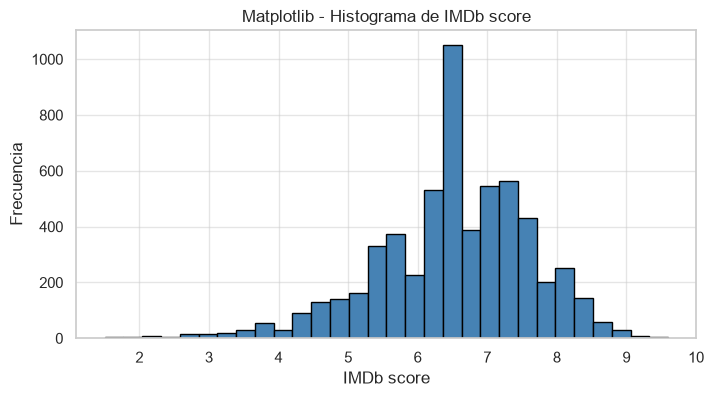

In [41]:
# Grafica 1: histograma de imdb_score
plt.figure(figsize=(8, 4))
plt.hist(data["imdb_score"], bins=30, color="steelblue", edgecolor="black")
plt.title("Matplotlib - Histograma de IMDb score")
plt.xlabel("IMDb score")
plt.ylabel("Frecuencia")
plt.show()

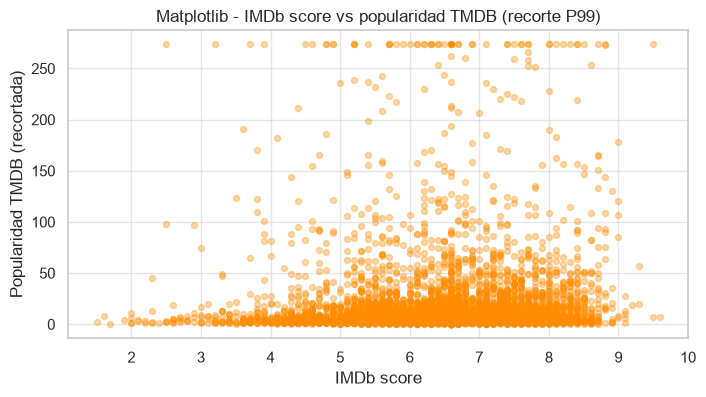

In [42]:
# Grafica 2: dispersion entre imdb_score y tmdb_popularity (recortada al P99)
plt.figure(figsize=(8, 4))
plt.scatter(data["imdb_score"], data["tmdb_popularity_clip"], alpha=0.35, s=18, color="darkorange")
plt.title("Matplotlib - IMDb score vs popularidad TMDB (recorte P99)")
plt.xlabel("IMDb score")
plt.ylabel("Popularidad TMDB (recortada)")
plt.show()

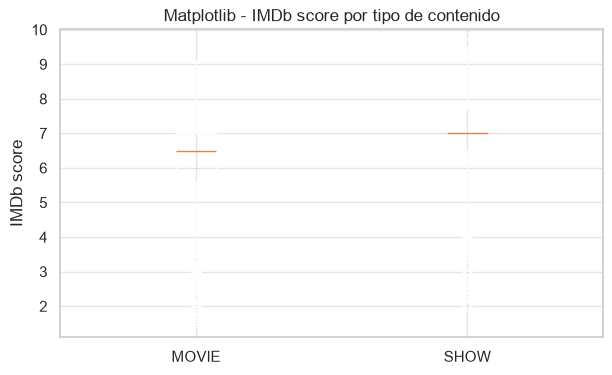

In [43]:
# Grafica 3: boxplot de imdb_score por tipo de contenido
movie = data.loc[data["type"] == "MOVIE", "imdb_score"]
show = data.loc[data["type"] == "SHOW", "imdb_score"]
plt.figure(figsize=(7, 4))
plt.boxplot([movie, show], tick_labels=["MOVIE", "SHOW"])
plt.title("Matplotlib - IMDb score por tipo de contenido")
plt.ylabel("IMDb score")
plt.show()

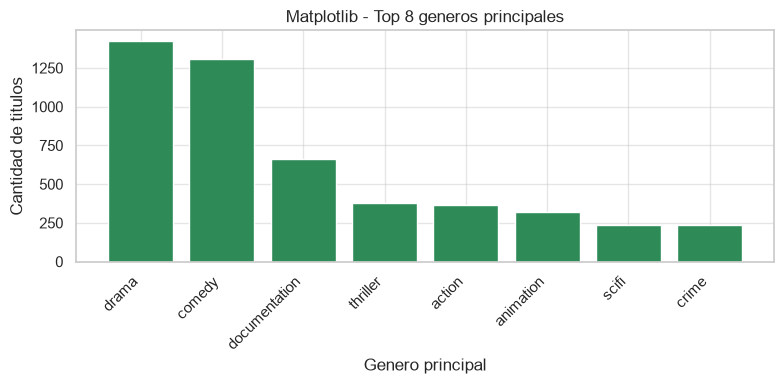

In [44]:
# Grafica 4: barras con el top 8 de generos principales
top_generos = data["primary_genre"].value_counts().head(8)
plt.figure(figsize=(8, 4))
plt.bar(top_generos.index, top_generos.values, color="seagreen")
plt.title("Matplotlib - Top 8 generos principales")
plt.xlabel("Genero principal")
plt.ylabel("Cantidad de titulos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Visualización con Seaborn (mínimo 3 gráficas)

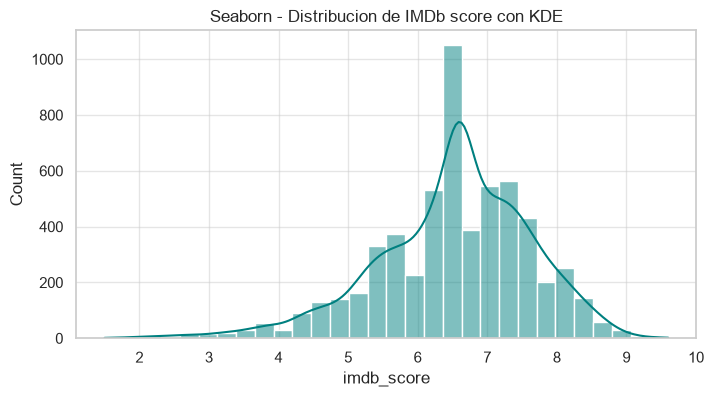

In [45]:
# Grafica 1: histplot con curva de densidad (KDE) de imdb_score
plt.figure(figsize=(8, 4))
sns.histplot(data=data, x="imdb_score", bins=30, kde=True, color="teal")
plt.title("Seaborn - Distribucion de IMDb score con KDE")
plt.show()

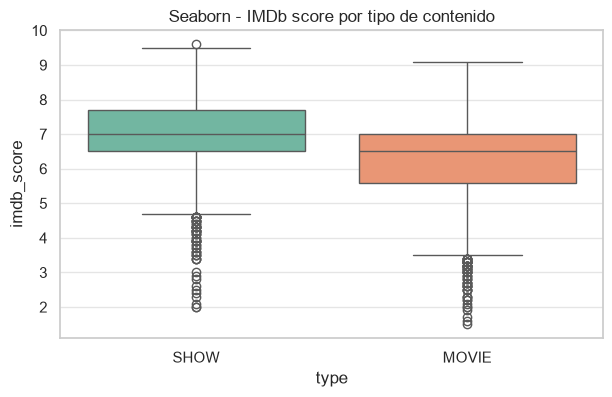

In [46]:
# Grafica 2: boxplot de imdb_score por tipo de contenido
plt.figure(figsize=(7, 4))
sns.boxplot(data=data, x="type", y="imdb_score", hue="type", palette="Set2", legend=False)
plt.title("Seaborn - IMDb score por tipo de contenido")
plt.show()

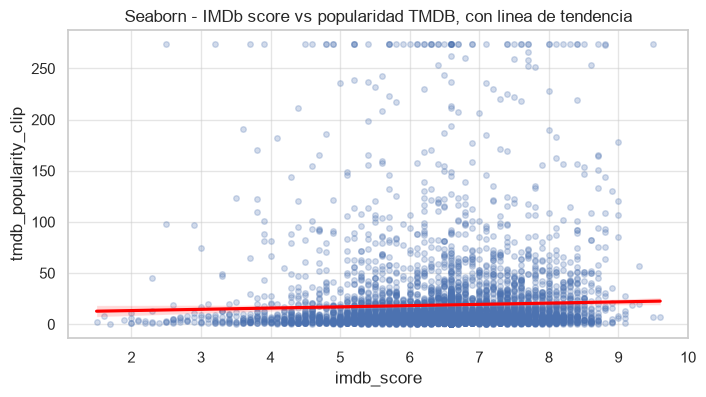

In [47]:
# Grafica 3: regplot entre imdb_score y popularidad TMDB (recortada)
plt.figure(figsize=(8, 4))
sns.regplot(data=data, x="imdb_score", y="tmdb_popularity_clip",
            scatter_kws={"alpha": 0.25, "s": 16}, line_kws={"color": "red"})
plt.title("Seaborn - IMDb score vs popularidad TMDB, con linea de tendencia")
plt.show()

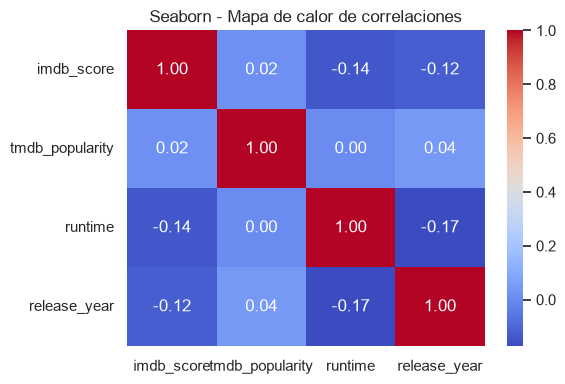

In [48]:
# Grafica 4: heatmap de correlaciones entre variables numericas
corr_df = data[["imdb_score", "tmdb_popularity", "runtime", "release_year"]].corr(numeric_only=True)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Seaborn - Mapa de calor de correlaciones")
plt.tight_layout()
plt.show()

**Comparación Matplotlib vs. Seaborn:** para el histograma y el *scatterplot*, Matplotlib exige definir manualmente cada elemento (bins, colores, ejes), lo que da mayor control fino pero requiere más código. Seaborn, en cambio, integra directamente la curva KDE en `histplot` y la línea de tendencia en `regplot` con una sola línea, además de manejar automáticamente la paleta de color por categoría en el `boxplot`. El `heatmap` de correlaciones sería mucho más tedioso de construir en Matplotlib puro (habría que anotar cada celda manualmente), mientras que en Seaborn es una sola instrucción. En síntesis, Matplotlib conviene cuando se necesita personalización total; Seaborn acelera gráficas estadísticas estándar y con mejor estética por defecto.

## 6. Respuestas analíticas y pensamiento crítico

**¿Qué fenómeno, proceso o contexto representa el *dataset*?**
El *dataset* representa el catálogo de contenido audiovisual (películas y series) disponible en Netflix hasta 2022, incluyendo metadatos de producción (año, duración, país, género, clasificación por edad) y métricas externas de recepción de audiencia (calificación y popularidad en IMDb y TMDB).

**¿Cuáles son las 5 variables más importantes para describir el caso y por qué?**
1. `type`: distingue películas de series, dos formatos con dinámicas de consumo y duración muy distintas.
2. `release_year`: permite entender la evolución temporal del catálogo y su crecimiento reciente.
3. `runtime`: refleja el formato y la duración típica de cada tipo de contenido.
4. `imdb_score`: mide la calidad percibida por la audiencia, clave para cualquier análisis de éxito de contenido.
5. `tmdb_popularity`: mide el alcance o interés generado, complementando al puntaje de calidad.

**¿Qué hallazgos se observan en la distribución de variables (categóricas y numéricas)?**
El catálogo está compuesto en su mayoría por películas (`MOVIE`) frente a series (`SHOW`). El `imdb_score` se concentra en valores medios-altos (entre 5.5 y 7.5) con una distribución que la prueba de Shapiro-Wilk descarta como normal. La `tmdb_popularity` presenta una fuerte asimetría a la derecha, con la mayoría de los títulos por debajo de 20 puntos y una cola de pocos títulos extremadamente populares. Los géneros principales más frecuentes son drama, comedia y documental.

**¿Qué relación relevante encontraron entre las variables? (mínimo 2)**
1. `imdb_score` y `tmdb_popularity` prácticamente no están correlacionadas (Pearson r ≈ 0.017, p ≈ 0.21, no significativa): un título bien calificado no garantiza ser popular, y viceversa. Calidad percibida y alcance de audiencia son fenómenos independientes en este catálogo.
2. El `imdb_score` sí difiere significativamente entre `MOVIE` y `SHOW` según la prueba t de Welch (p « 0.05): las series tienen, en promedio, una calificación IMDb más alta que las películas (6.95 vs. 6.28).

**¿Qué problemas de calidad de datos detectaron y cómo los abordan?**
Se detectaron valores nulos en `age_certification` (imputados como "No clasificado" por su alta proporción), nulos estructurales en `seasons` (imputados con 0 en películas), nulos en las métricas de IMDb/TMDB (imputados con la mediana para no perder observaciones), y registros con `runtime == 0` que se trataron como faltantes e imputaron con la mediana según el tipo de contenido. También se identificaron valores atípicos de alta popularidad en `tmdb_popularity`, que se conservaron para el análisis estadístico pero se recortaron al percentil 99 solo para efectos de visualización.

**Con base en lo observado: ¿qué pregunta de IA o problema predictivo podría plantearse a futuro con este *dataset*?**
Podría plantearse un problema de **regresión** para predecir `imdb_score` o `tmdb_popularity` a partir de variables como `type`, `primary_genre`, `release_year` y `runtime`, o un problema de **clasificación** para predecir si un título será "popular" (por ejemplo, superando cierto umbral de `tmdb_popularity`) usando esas mismas variables, útil para decisiones de adquisición o promoción de contenido.

### Pensamiento crítico adicional

- **¿Cuándo conviene usar Matplotlib y cuándo Seaborn?** Matplotlib es preferible cuando se necesita control total sobre cada elemento gráfico o gráficas muy personalizadas; Seaborn conviene para explorar rápidamente distribuciones, relaciones y correlaciones con menos código y mejor estética por defecto.
- **¿Qué ventajas aporta NumPy frente a trabajar solo con listas de Python?** Permite operaciones vectorizadas (sin ciclos explícitos) sobre arreglos completos, con mejor rendimiento y una sintaxis más compacta para estadísticos y transformaciones.
- **¿Qué aporta SciPy que NumPy/Pandas no ofrecen directamente?** Pruebas estadísticas inferenciales listas para usar (normalidad, correlación con p-valor, pruebas t) que en NumPy o Pandas habría que implementar manualmente.
- **¿Qué otra herramienta usarían para un futuro modelado de IA con este *dataset*?** Scikit-learn, por su ecosistema integrado de preprocesamiento, entrenamiento y validación de modelos de regresión o clasificación de forma reproducible.
- **¿Qué limitaciones tiene este *dataset*?** Posible sesgo hacia contenido reciente (mayor concentración desde 2016), ausencia de datos de consumo real dentro de la plataforma (solo métricas externas de IMDb/TMDB), y una proporción considerable de valores faltantes en clasificación por edad y calificaciones.

### Referencias

Boschetti, A., & Massaron, L. (2018). *Python data science essentials: A practitioner's guide covering essential data science principles, tools, and techniques*. Packt Publishing Ltd.

Fuentes, A. (2018). *Become a python data analyst: Perform exploratory data analysis and gain insight into scientific computing using python*. Packt Publishing, Limited.

Mehta, H. (2015). *Mastering Python scientific computing*. Packt Publishing, Limited.

Soeiro, V. (2022). *Netflix TV shows and movies* [Data set]. Kaggle. https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies

Yim, A., Chung, C., & Yu, A. (2018). *Matplotlib for python developers: Effective techniques for data visualization with python* (2nd ed.). Packt Publishing, Limited.